In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [3]:
from google.colab import files
uploaded = files.upload()

Saving heart_dataset.csv to heart_dataset.csv


In [5]:
import pandas as pd

df = pd.read_csv("heart_dataset.csv")
df.head()

,Age,Sex,Cholesterol,BloodPressure,HeartRate,Target
0,67,0,184,98,124,0
1,57,1,198,160,113,1
2,43,0,166,117,167,0
3,71,1,195,167,64,0
4,36,0,266,141,153,1


In [7]:
print(df.columns)

Index(['Age', 'Sex', 'Cholesterol', 'BloodPressure', 'HeartRate', 'Target'], dtype='object')


In [10]:
# Automatically detect target column
for col in df.columns:
    if col.lower() in ['target', 'output', 'num', 'heartdisease']:
        target_col = col

print("Target column is:", target_col)

X = df.drop(target_col, axis=1)
y = df[target_col]

Target column is: Target


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
print(X.head())
print(y.head())

   Age  Sex  Cholesterol  BloodPressure  HeartRate
0   67    0          184             98        124
1   57    1          198            160        113
2   43    0          166            117        167
3   71    1          195            167         64
4   36    0          266            141        153
0    0
1    1
2    0
3    0
4    1
Name: Target, dtype: int64


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
from sklearn.metrics import accuracy_score

In [17]:
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))

DT Accuracy: 0.575


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.5


In [19]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.45


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [22]:
print("\nModel Comparison:")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))


Model Comparison:
Logistic Regression: 0.4
Decision Tree: 0.575
Random Forest: 0.5
SVM: 0.45


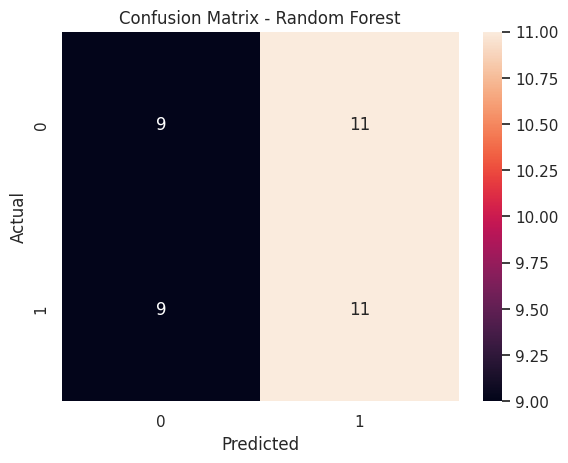

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.45      0.47        20
           1       0.50      0.55      0.52        20

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.50        40
weighted avg       0.50      0.50      0.50        40



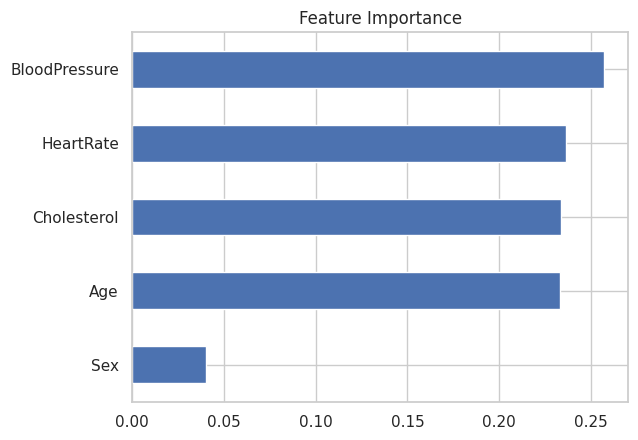

In [26]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)

plt.figure()
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [27]:
sample = X_test[0].reshape(1, -1)

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

No Heart Disease


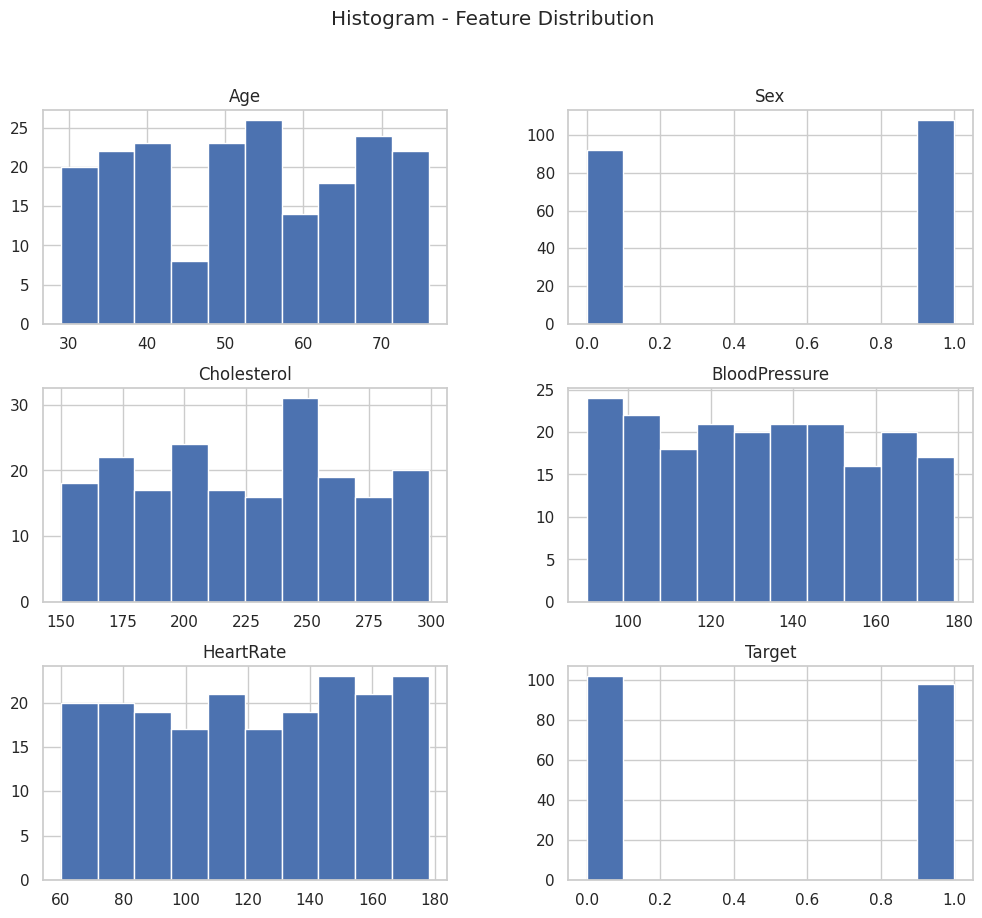

In [28]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.suptitle("Histogram - Feature Distribution")
plt.show()

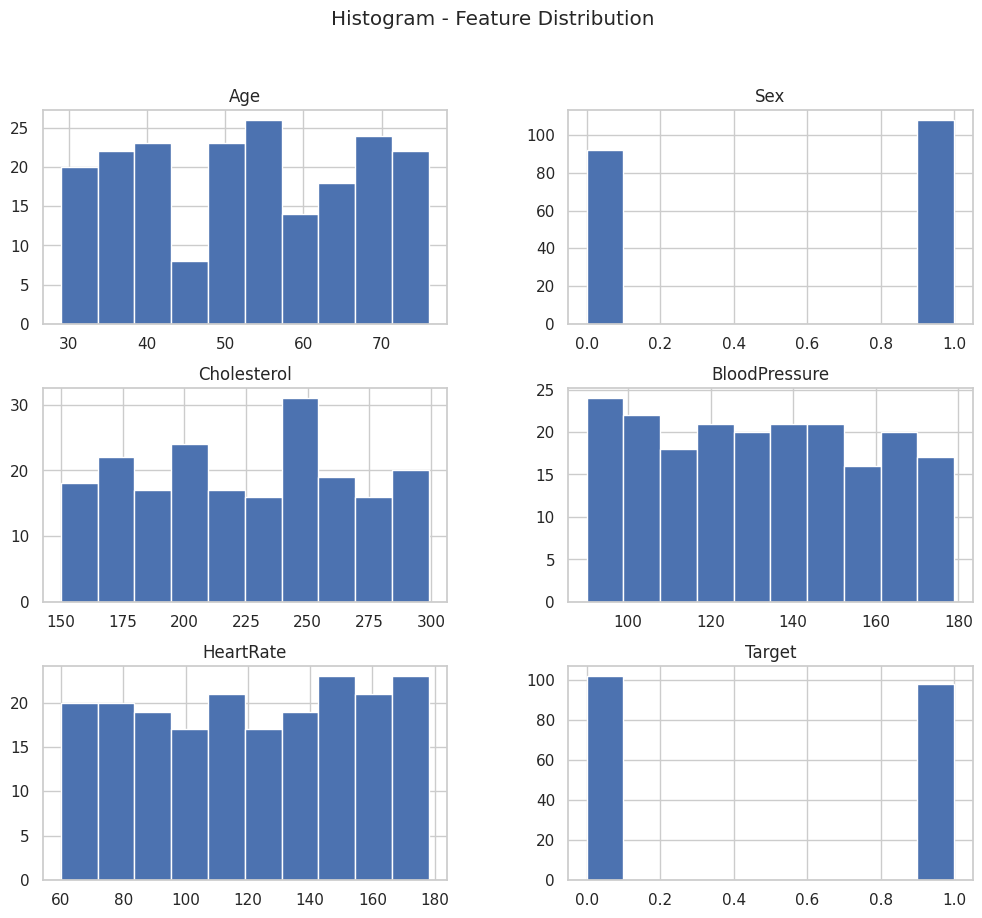

In [29]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.suptitle("Histogram - Feature Distribution")
plt.show()

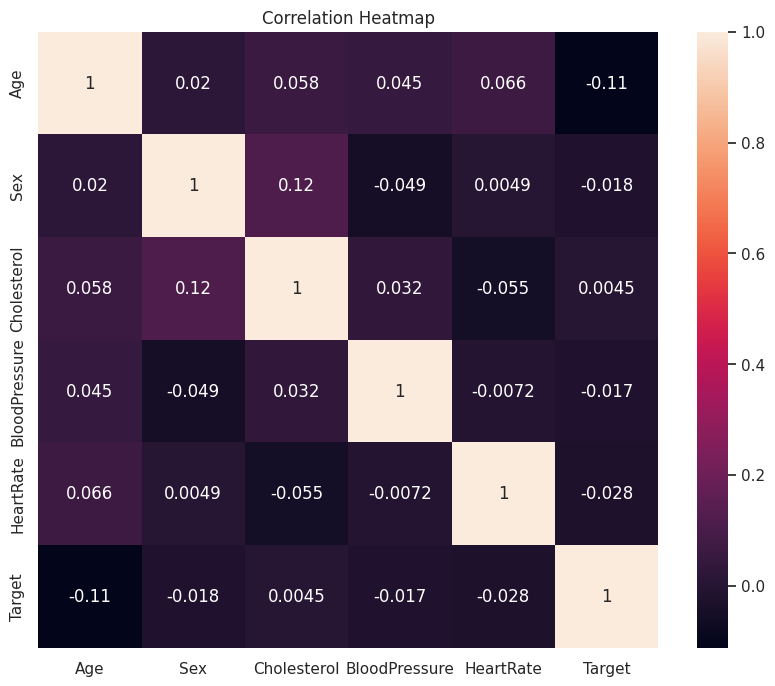

In [31]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

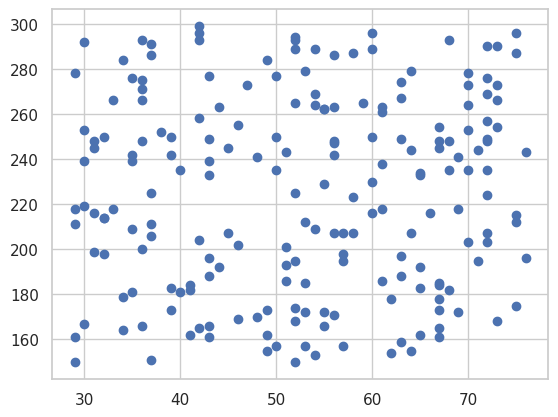

In [32]:
plt.scatter(df['Age'], df['Cholesterol'])